# `sc-tap` — Side-constrained (capacitated) user equilibrium (Larsson & Patriksson 1995)

**What.** Side-constrained UE adds a hard per-link capacity `v_a ≤ u_a` on top of the
BPR latency. At the equilibrium the KKT multiplier of a binding constraint acts as a
queueing delay, so travellers equalize the *capacity-augmented* cost `t_a + β_a`, not
the raw cost. `sc-tap` solves the augmented Wardrop problem
(`[larsson1995augmented]`, [docs/REFERENCES.md](../../docs/REFERENCES.md)).

**Why it is in the benchmark.** It is the capacitated branch of UE (ADR-009): a binding
capacity makes the raw gap non-zero while the augmented equilibrium holds. See the
[model compendium](../../docs/MODELS.md) and
[docs/ARCHITECTURE.md](../../docs/ARCHITECTURE.md) (P1).

**Scope.** Runs on the built-in side-constrained anchor (demand 10, capacity 4 on link
3→2) and certifies capacity feasibility and the binding-constraint anchor.

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** Every scored
quantity below is recomputed live by the P1 `Evaluator` from the flows the model
emitted, in the cell where it is claimed. Model self-reports are shown only as
provenance and diffed against the certificate as an honesty check, exactly as the
harness treats them ([README](../../README.md), *Certified, not self-reported*).

In [1]:
# Setup. `sc-tap` is a core model: a plain `pip install -e .` suffices — no
# optional extra, so no guard cell. The inline backend is Agg-based (headless CI
# renders into the notebook); NEVER matplotlib.use("Agg") in-kernel — it silently
# suppresses inline figure capture.
%matplotlib inline
import numpy as np

from tabench import (
    Budget,
    Evaluator,
    RngBundle,
    SideConstrainedModel,
    Trace,
    sc_two_route_scenario,
    viz,
)

## The scenario

Two disjoint 2-link routes, demand 10, a hard capacity of 4 on the route-A link 3→2.
Plain UE would put f_A = 5.5 there, so the capacity binds: f_A = 4, f_B = 6, with a
queueing multiplier β = 1 + D − 2·cap = 3. Content-hashed (P2).

In [2]:
scenario = sc_two_route_scenario()
net = scenario.network

print(f"scenario      : {scenario.name}")
print(f"content hash  : {scenario.content_hash()[:16]}…")
print(f"total demand  : {scenario.demand.total}")
print(f"side capacities: {scenario.side_capacities}  (link 3->2 capped at 4)")

scenario      : sc-tworoute
content hash  : 0dc8ae19da506625…
total demand  : 10.0
side capacities: [1.e+06 4.e+00 1.e+06 1.e+06]  (link 3->2 capped at 4)


## Solve

The model contract ([CONTRIBUTING.md](../../CONTRIBUTING.md)): a model receives
`(scenario, budget, rng, trace)`, records checkpoints, and respects the budget.
Budgets are hardware-free (iterations / shortest-path calls; wall-clock is recorded
but never the ranking axis, P7). Whatever the model writes into `self_report` is
provenance, not a score.

In [3]:
model = SideConstrainedModel()
bundle = model.solve(scenario, Budget(iterations=100), RngBundle(0), Trace())

final = bundle.final
print(f"model                 : {model.name}")
print(f"emitted flows         : {np.round(final.link_flows, 6)}")
print(f"self Wardrop gap       : {final.self_report['relative_gap']:.3e}  (provenance only)")
print(f"self augmented gap     : {final.self_report['augmented_relative_gap']:.3e}  (provenance only)")
print(f"self max multiplier    : {final.self_report['max_multiplier']:.4f}  (queue delay, provenance)")

model                 : sc-tap
emitted flows         : [4. 4. 6. 6.]
self Wardrop gap       : 2.647e-01  (provenance only)
self augmented gap     : 5.099e-11  (provenance only)
self max multiplier    : 3.0000  (queue delay, provenance)


## Certify (P1)

The scored certificate is **capacity feasibility**: the harness recomputes the maximum
capacity violation and confirms `sc_capacity_feasible = 1`. The ordinary Wardrop gap is
*non-zero* — the binding capacity creates a queueing delay, so raw costs are unequal —
and the model equalizes the augmented cost instead (its `augmented_relative_gap ≈ 0` is
provenance). We recompute the binding anchor (f_A = 4, f_B = 6) in-cell.

In [4]:
evaluator = Evaluator(scenario)
metrics = evaluator.evaluate(final.link_flows)
gap = metrics["relative_gap"]
print(f"Wardrop relative gap    : {gap:.3e}   (non-zero: binding capacity -> queue delay)")
print(f"max capacity violation  : {metrics['max_capacity_violation']:.2e}")
print(f"capacity feasible       : {metrics['sc_capacity_feasible']:.0f}")
print(f"feasible                : {metrics['feasible']:.0f}")

assert metrics["feasible"] == 1.0
assert metrics["sc_capacity_feasible"] == 1.0
assert metrics["max_capacity_violation"] < 1e-6

# Honesty diff (P1): the (non-zero) raw Wardrop gap self-report matches the certificate.
assert np.isclose(final.self_report["relative_gap"], gap, rtol=1e-9, atol=1e-9)

# Analytic anchor RECOMPUTED: capacity 4 binds -> f_A = cap, f_B = D - cap.
demand = scenario.demand.total
cap = float(scenario.side_capacities[1])  # the capacity on link 3->2
ref_flows = np.array([cap, cap, demand - cap, demand - cap])
print(f"binding anchor f_A, f_B : {cap}, {demand - cap}  (recomputed)")
assert np.allclose(final.link_flows, ref_flows, atol=1e-4)

# The two counterfactuals named in the Scope markdown, recomputed (not quoted).
# Plain (uncapacitated) UE equalizes 1+f_A = 2+f_B with f_A+f_B=D -> f_A*=(D+1)/2.
plain_ue_f_a = 0.5 * (demand + 1.0)
print(f"plain-UE counterfactual f_A : {plain_ue_f_a}  (capacity {cap} binds below it)")
assert np.isclose(plain_ue_f_a, 5.5)
assert cap < plain_ue_f_a  # confirms the capacity actually binds

# The queueing multiplier beta = c_B(D-cap) - c_A(cap) = (2+D-cap) - (1+cap) = 1+D-2*cap,
# checked against the model's own self-reported max_multiplier (provenance).
beta = 1.0 + demand - 2.0 * cap
print(f"queueing multiplier beta    : {beta}  (self-report: "
      f"{final.self_report['max_multiplier']:.4f})")
assert np.isclose(beta, 3.0)
assert np.isclose(final.self_report["max_multiplier"], beta, atol=1e-4)

Wardrop relative gap    : 2.647e-01   (non-zero: binding capacity -> queue delay)
max capacity violation  : 6.37e-11
capacity feasible       : 1
feasible                : 1
binding anchor f_A, f_B : 4.0, 6.0  (recomputed)
plain-UE counterfactual f_A : 5.5  (capacity 4.0 binds below it)
queueing multiplier beta    : 3.0  (self-report: 3.0000)


## Visualize

Both figures come from `tabench.viz`. Left/top: the side-constrained link flows — the
capped link 3→2 carries exactly its capacity 4. Right/bottom: the emitted flows against
the recomputed binding anchor — on-diagonal at (4, 4, 6, 6).

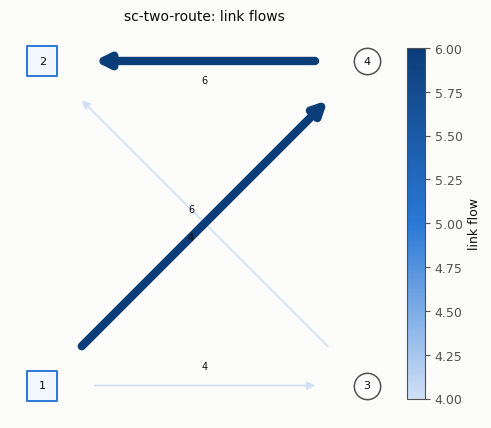

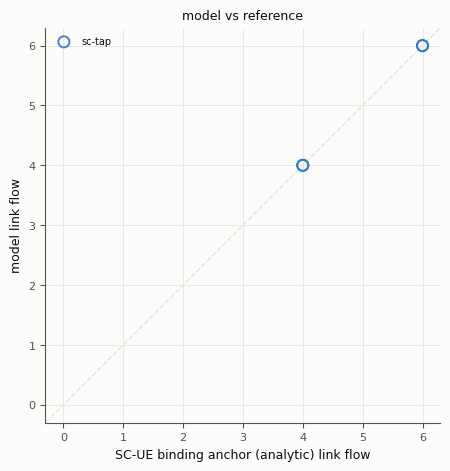

In [5]:
display(viz.plot_network_flows(net, final.link_flows))
display(viz.plot_flow_scatter(("SC-UE binding anchor (analytic)", ref_flows), {"sc-tap": final.link_flows}))

## Takeaways & pointers

- **Capacity is the certificate.** `sc_capacity_feasible = 1`, zero violation; the raw
  Wardrop gap is non-zero because the queue delay makes raw costs unequal (reported).
- **Augmented equilibrium.** The flow equalizes `t_a + β_a`, the model's provenance
  `augmented_relative_gap ≈ 0`.
- **Where next.** Uncapacitated UE: [`bfw`](05-bfw.ipynb); ADR-009 in the
  [model compendium](../../docs/MODELS.md).